In [1]:
import random
import numpy as np
from pathlib import Path
from the_well.data import WellDataset

import torch
from torch.utils.data import DataLoader

from modules import *
from losses import *
from datasets import HelmholtzDataset
from vis_tools import *

In [ ]:
SEED         = 42
EPOCHS       = 6
BATCH_SIZE   = 24
LR           = 1e-3

BASE_PATH = "/mnt/storage_C1/BILL_pino"
DATASET_NAME = "helmholtz_staircase"
DATASET_PATH = BASE_PATH + "/the_well/datasets/" + DATASET_NAME
OUTPUT_DIR   = BASE_PATH + '/models/' + DATASET_NAME


MODES1       = 16   # Modos de Fourier na primeira dimensão espacial (x)
MODES2       = 16   # Modos de Fourier na segunda dimensão espacial (y)
WIDTH        = 32   # Número de canais internos (largura do modelo)
DEPTH        = 4    # Quantidade de camadas de Fourier
PROJ_DIM     = 128  # Dimensão da MLP de projeção para a saída

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128


In [4]:
train_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="train"
)

validation_dataset = WellDataset(
    path=DATASET_PATH,
    well_split_name="valid"
)

train_ds = HelmholtzDataset(train_dataset)
val_ds = HelmholtzDataset(validation_dataset)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=16,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=False,
)

/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
Epoch 1/6: 100%|██████████| 850/850 [16:26<00:00,  1.16s/it, loss=0.178297]
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` 

Epoch 001 | train = 0.178297 | val = 0.048075 | best_val = 0.048075


Epoch 2/6: 100%|██████████| 850/850 [17:05<00:00,  1.21s/it, loss=0.040040]
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` 

Epoch 002 | train = 0.040040 | val = 0.034434 | best_val = 0.034434


Epoch 3/6: 100%|██████████| 850/850 [16:15<00:00,  1.15s/it, loss=0.028733]
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` 

...

Epoch 004 | train = 0.018894 | val = 0.018326 | best_val = 0.018326


Epoch 5/6: 100%|██████████| 850/850 [13:52<00:00,  1.02it/s, loss=0.012870]
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` 

Epoch 005 | train = 0.012870 | val = 0.013707 | best_val = 0.013707


Epoch 6/6: 100%|██████████| 850/850 [13:06<00:00,  1.08it/s, loss=0.010395]
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(
/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` 

Epoch 006 | train = 0.010395 | val = 0.010627 | best_val = 0.010627


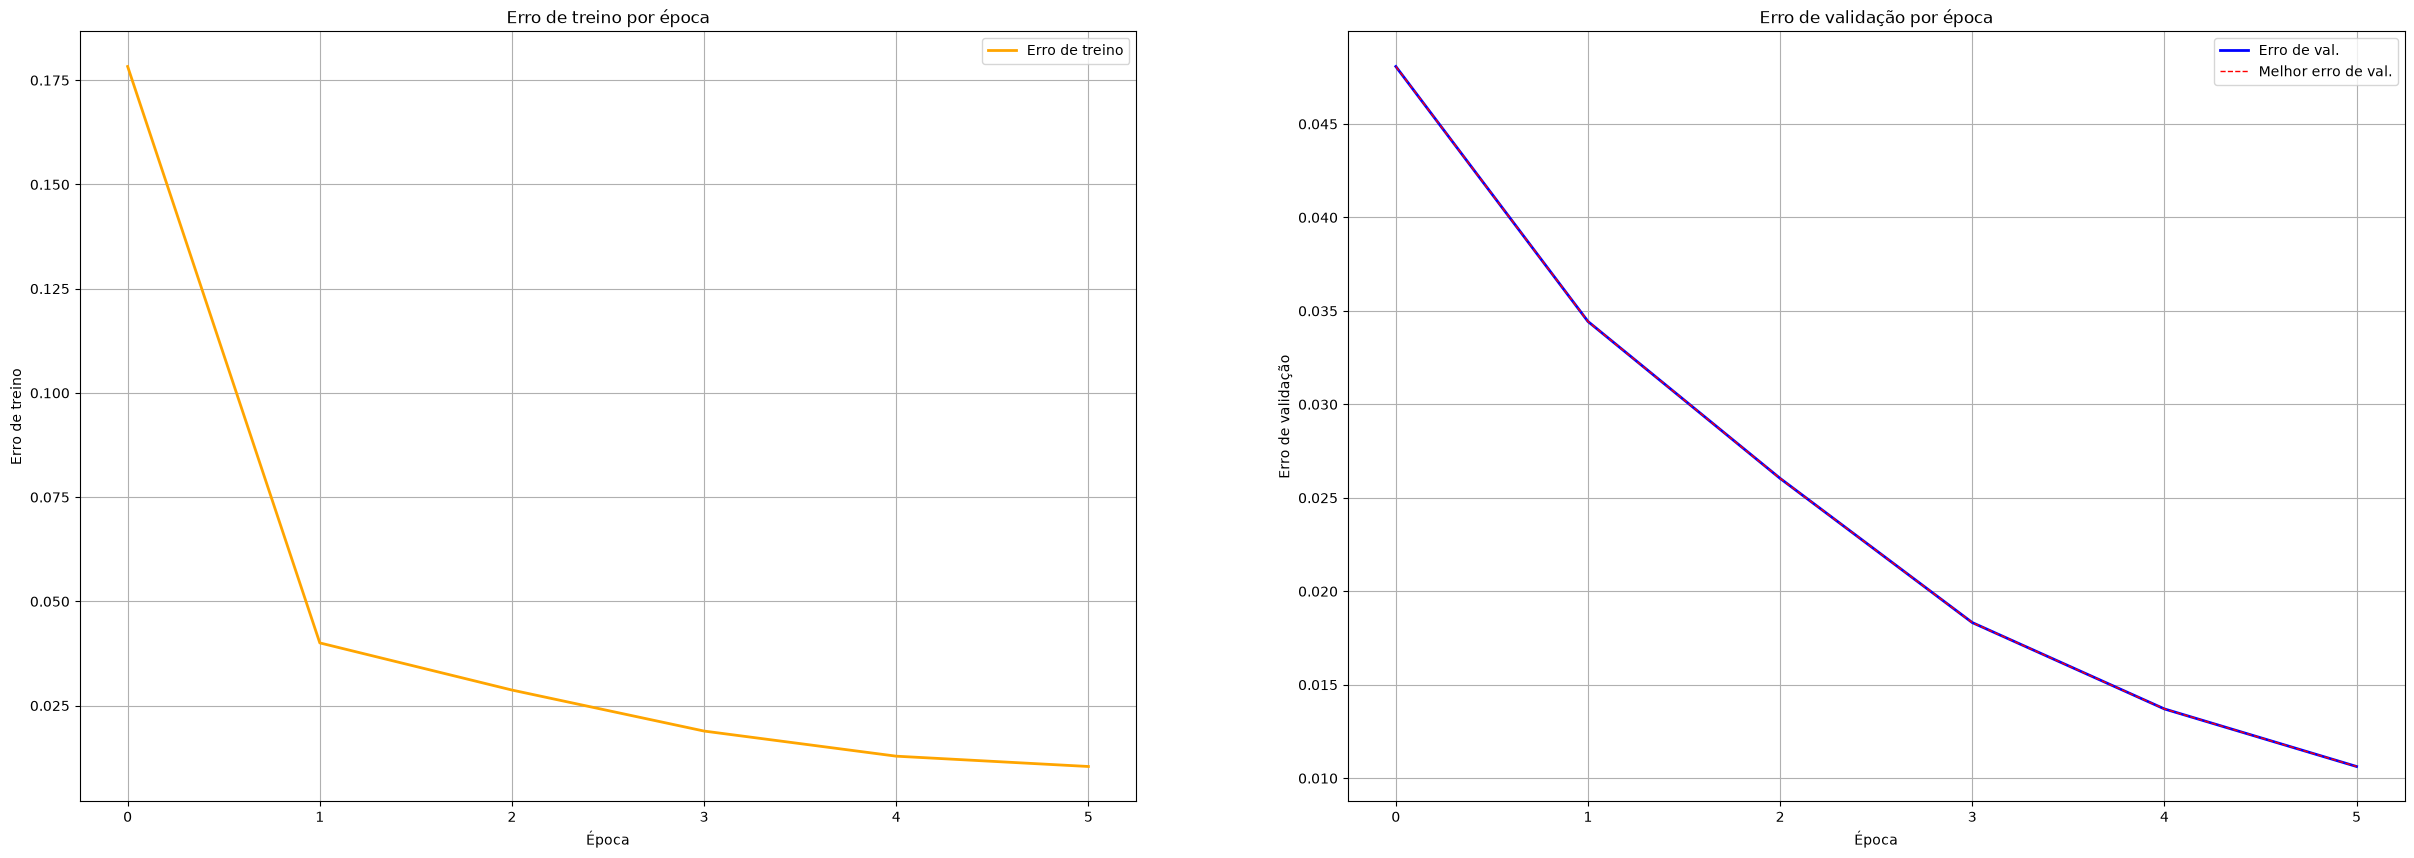

/home/al.lucas.goncalves/ml2/AV2_ML2_IMPA/.venv/lib/python3.12/site-packages/the_well/data/datasets.py:736: RuntimeWarning: Only axis-aligned boundary fully supported. Boundary for axis counted as `open` or `periodic` if any part of it is and `wall` otherwise.If this does not fit your desired usecase, set `boundary_return_type=None`.
  warnings.warn(


AttributeError: 'numpy.ndarray' object has no attribute 'permute'

<Figure size 640x480 with 0 Axes>

In [ ]:
NUM_EXPS = 5

experiments = {
    'experiment_name': ['fno2d',"fno2dv1","dsfno2d","prebbfno2d","bbfno2"],
    'experiment_model': [FNO2d, FNO2d_v1, DoubleSkipFNO2d, BackbonePreFNO2d, BackboneFNO2d],
    'experiment_label': ['fno2d',"fno2dv1","dsfno2d","prebbfno2d","bbfno2"],
}

x, y = train_ds[0]
in_dim, out_dim = x.shape[-1], y.shape[-1] 

for i in range(1, NUM_EXPS):

    model = experiments['experiment_model'][i](
        modes1=MODES1,
        modes2=MODES2,
        width=WIDTH,
        in_dim=in_dim,
        out_dim=out_dim,
        depth=DEPTH,
        proj_dim=PROJ_DIM
    ).cuda()

    model = torch.compile(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
    )

    criterion = relative_l2_loss

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=EPOCHS,
        checkpoint_dir=OUTPUT_DIR,
        label=experiments['experiment_label'][i]
    )

    train_vis = plot(history, OUTPUT_DIR + '/plots/' + experiments['experiment_label'][i])

    train_vis.show(save=True)

    model_vis = gif(val_ds, model, experiments['experiment_label'][i], device, OUTPUT_DIR + '/gifs/' + experiments['experiment_label'][i])

    model_vis.show(steps=200)


    